# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Потапова Світлана'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 16     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Потапова Світлана, ШІ-31, варіант 16
ваш потік:                   P>5
ваша пара для графіка 3:     радіопотік F10.7 та швидкість вітру
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      У яку добу середнє значення вашого потоку було найбільшим? А найменшим?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
df = pd.read_excel(ФАЙЛ)

display(df.head())

print(df.dtypes)


,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

Результат виявився дивним через те, що на початку файлу містяться службові текстові рядки, а не сама таблиця. Замість заголовків у першому рядку знаходяться посилання та пусті комірки, тому більшість стовпців мають назви unnamed, а а через наявність тексту в рядках самі стовпці набули типу object

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
print(RAW.shape)
display(RAW.head(30))



(7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
print(RAW.notna().sum())

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

У аркуші 3 таблиці:
Перша займає стовпці 1-14, друга 16-19, третя 24-31

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
# ВАШ КОД
print("Таблиця A")
print(RAW.iloc[0:23, 1].dropna())

print("\nТаблиця B")
print(RAW.iloc[13:25, 16].dropna())

print("\nТаблиця  C")
print(RAW.iloc[0:8, 26].dropna())

Таблиця A
0           ftp://ftp.swpc.noaa.gov/pub/lists/particle/
2                   :Data_list: 20170901_Gs_part_5m.txt
3                        :Created: 2017 Sep 02 0011 UTC
4     # Prepared by the U.S. Dept. of Commerce, NOAA...
5     # Please send comments and suggestions to SWPC...
6                                                    # 
7                  # Label: P > 1 = Particles at >1 Mev
8                  # Label: P > 5 = Particles at >5 Mev
9                 # Label: P >10 = Particles at >10 Mev
10                # Label: P >30 = Particles at >30 Mev
11                # Label: P >50 = Particles at >50 Mev
12               # Label: P>100 = Particles at >100 Mev
13               # Label: E>0.8 = Electrons at >0.8 Mev
14               # Label: E>2.0 = Electrons at >2.0 Mev
15               # Label: E>4.0 = Electrons at >4.0 Mev
16                # Units: Particles = Protons/cm2-s-sr
17              # Units: Electrons = Electrons/cm2-s-sr
18                                    

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | NOAA Space Weather Prediction Center (GOES-15) | Protons/cm2-s-sr, Electrons/cm2-s-sr|
| B | NOAA Space Weather Prediction Center (Daily Solar Data) | Одиниця сонячного потоку (sfu) |
| C | SOHO CELIAS Proton Monitor | Швидкість km/sec, густина protons/cm3 |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД
A = RAW.iloc[26:7226, 1:15].copy()
B = RAW.iloc[27:52, 16:20].copy()
C = RAW.iloc[27:628, 24:32].copy()

A.columns = ['YR', 'MO', 'DA', 'HHMM', 'Julian_Day', 'Sec_of_Day', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
B.columns = ['YR', 'MO', 'DA', 'F10.7']
C.columns = ['idx1', 'idx2', 'YR', 'MO', 'DA', 'HH', 'SPEED', 'DENSITY']

for df in [A, B, C]:
  for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
# ВАШ КОД
A['ts'] = pd.to_datetime(
    A['YR'].astype(int).astype(str) + '-' +
    A['MO'].astype(int).astype(str).str.zfill(2) + '-' +
    A['DA'].astype(int).astype(str).str.zfill(2) + ' ' +
    A['HHMM'].astype(int).astype(str).str.zfill(4),
    format='%Y-%m-%d %H%M'
)

B['ts'] = pd.to_datetime(
    B['YR'].astype(int).astype(str) + '-' +
    B['MO'].astype(int).astype(str).str.zfill(2) + '-' +
    B['DA'].astype(int).astype(str).str.zfill(2)
)

C['ts'] = pd.to_datetime(
    '20' + C['YR'].astype(int).astype(str) + '-' +
    C['MO'].astype(int).astype(str).str.zfill(2) + '-' +
    C['DA'].astype(int).astype(str).str.zfill(2) + ' ' +
    C['HH'].astype(int).astype(str).str.zfill(2) + ':00'
)

print("A:", A['ts'].min(), "-", A['ts'].max())
print("B:", B['ts'].min(), "-", B['ts'].max())
print("C:", C['ts'].min(), "-", C['ts'].max())

A: 2017-08-28 00:00:00 - 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 - 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 - 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
# ВАШ КОД
for table_name, table in [('A', A), ('B', B), ('C', C)]:
  print(f"Аналіз таблиці {table_name}\n")
  print(f"Розмір таблиці: {table.shape}\n")

  cols_info = pd.DataFrame({
      'Тип стовпця': table.dtypes,
      'Кількість пропусків': table.isna().sum()
  })

  print(f"Типи стовпців та кількість пропусків у них:")
  print(cols_info)

  duplicates_count = table.duplicated().sum()
  print(f"\nКількість повних дублікатів рядків: {duplicates_count}\n")

  print(f"Описова статистика таблиці:")
  print(table.describe())
  print("\n\n")


Аналіз таблиці A

Розмір таблиці: (7200, 15)

Типи стовпців та кількість пропусків у них:
               Тип стовпця  Кількість пропусків
YR                   int64                    0
MO                   int64                    0
DA                   int64                    0
HHMM                 int64                    0
Julian_Day           int64                    0
Sec_of_Day           int64                    0
P>1                float64                    3
P>5                float64                    3
P>10               float64                    3
P>30               float64                    3
P>50               float64                    3
P>100              float64                    3
E>0.8              float64                    3
E>2.0              float64                    3
ts          datetime64[ns]                    0

Кількість повних дублікатів рядків: 0

Описова статистика таблиці:
           YR           MO           DA         HHMM    Julian_Day    Sec_

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
# ВАШ КОД

speed_mean_before = C['SPEED'].mean()
speed_min_before = C['SPEED'].min()
speed_neg_count = (C['SPEED'] < 0 ).sum()

density_mean_before = C['DENSITY'].mean()
density_min_before = C['DENSITY'].min()
density_neg_count = (C['DENSITY'] < 0).sum()

C.loc[C['SPEED']< 0, 'SPEED'] = float('nan')
C.loc[C['DENSITY']< 0, 'DENSITY'] = float('nan')

speed_mean_after = C['SPEED'].mean()
speed_min_after = C['SPEED'].min()

density_mean_after = C['DENSITY'].mean()
density_min_after = C['DENSITY'].min()

print(f"Кількість від'ємних значень у стовпці 'SPEED': {speed_neg_count}")
print(f"Кількість від'ємних значень у стовпці 'DENSITY': {density_neg_count}")

comparison_table = pd.DataFrame({
    'Метрика': [
        'SPEED (Середнє)',
        'SPEED (Мінімум)',
        'DENSITY (Середнє)',
        'DENSITY (Мінімум)'
    ],
    'До': [
        speed_mean_before,
        speed_min_before,
        density_mean_before,
        density_min_before
    ],
    'Після': [
        speed_mean_after,
        speed_min_after,
        density_mean_after,
        density_min_after
    ]
})


print("\nПорівняння метрик:\n")
print(comparison_table.to_string(index=False))



Кількість від'ємних значень у стовпці 'SPEED': 8
Кількість від'ємних значень у стовпці 'DENSITY': 8

Порівняння метрик:

          Метрика         До      Після
  SPEED (Середнє) 506.547421 513.394604
  SPEED (Мінімум)  -1.000000 277.000000
DENSITY (Середнє)   2.907654   2.960371
DENSITY (Мінімум)  -1.000000   0.100000


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

-1 - це значення, які свідчать про відсутність даних. У обох стовпцях їх 8. Через наявність -1, середнє було занижене, а мінімумом стовпців було несправжнє значення

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
# ВАШ КОД
cols = ['YR', 'MO', 'DA', 'HHMM', 'Julian_Day', 'Sec_of_Day', 'ts']

print(A[cols].describe())

           YR           MO           DA         HHMM    Julian_Day    Sec_of_Day                   ts
count  7200.0  7200.000000  7200.000000  7200.000000   7200.000000   7200.000000                 7200
mean   2017.0     8.840000    13.960000  1177.500000  58005.000000  43050.000000  2017-09-09 11:57:30
min    2017.0     8.000000     1.000000     0.000000  57993.000000      0.000000  2017-08-28 00:00:00
25%    2017.0     9.000000     7.000000   588.750000  57999.000000  21525.000000  2017-09-03 05:58:45
50%    2017.0     9.000000    13.000000  1177.500000  58005.000000  43050.000000  2017-09-09 11:57:30
75%    2017.0     9.000000    19.000000  1766.250000  58011.000000  64575.000000  2017-09-15 17:56:15
max    2017.0     9.000000    31.000000  2355.000000  58017.000000  86100.000000  2017-09-21 23:55:00
std       0.0     0.366632     8.775483   692.481902      7.211603  24943.113498                  NaN


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Такими стовпцям є усі стовпці що стосуються часу: YR, MO, DA, HHMM, Julian_Day, Sec_of_Day, ts
Обчислення середнього або стандартного відхилення для них немає сенсу, бо це часові мітки, які відображають хронологію дослідження, вони не є вимірюваннями фізичних явищ, "середній" місяць чи день не дають нам ніякої інформації про досліджуваний процес

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
# ВАШ КОД
flux_cols = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_hourly = A.resample('1h', on='ts')[flux_cols].agg(['mean', 'max'])
A_hourly.columns = [f"{col}_{stat}" for col, stat in A_hourly.columns]

A_hourly = A_hourly.reset_index()

A_hourly.head()


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

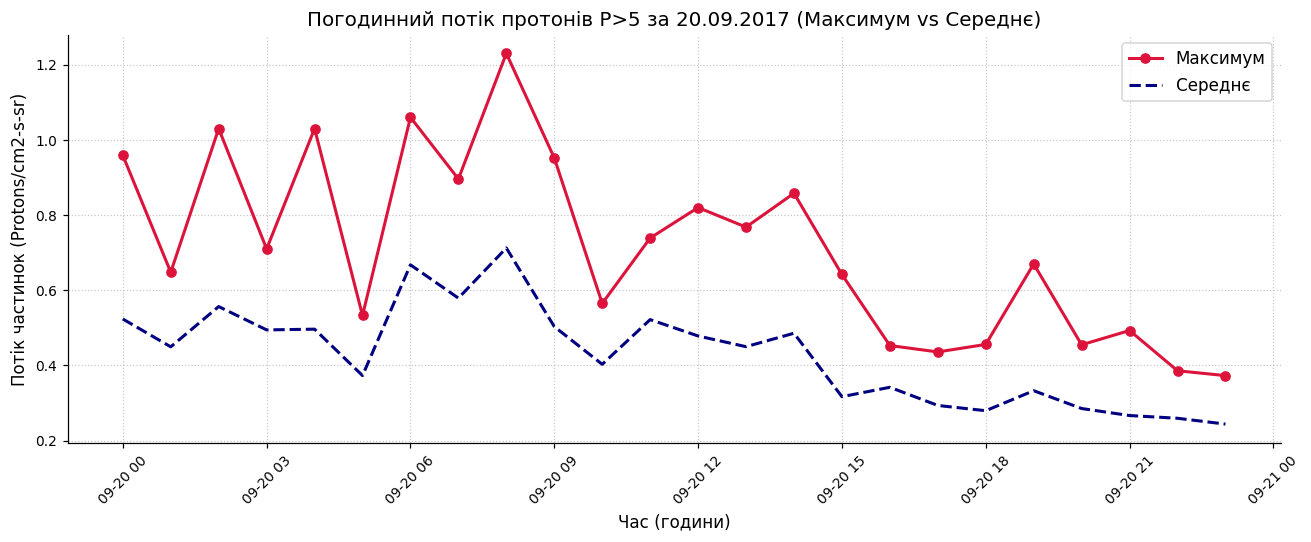

In [15]:
# ВАШ КОД
import matplotlib.pyplot as plt

day_data = A_hourly[A_hourly['ts'].dt.date == pd.to_datetime('2017-09-20').date()].copy()

plt.figure(figsize=(12, 5))

plt.plot(day_data['ts'], day_data['P>5_max'], label='Максимум', color='crimson', linewidth=2, marker='o')

plt.plot(day_data['ts'], day_data['P>5_mean'], label='Середнє', color='navy', linestyle='--', linewidth=2)

plt.title("Погодинний потік протонів P>5 за 20.09.2017 (Максимум vs Середнє)", fontsize=13)
plt.xlabel("Час (години)", fontsize=11)
plt.ylabel("Потік частинок (Protons/cm2-s-sr)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Крива максимуму завжди лежить вище за криву середнього, оскільки вона фіксує найсильніші піки потоку за кожну годину. Крива середнього згладжує ці коливання і показує загальний фоновий рівень радіації. Різниця між ними стає суттєвою під час раптових, спалахових подій. Наприклад, якщо протягом години стався сильний, але короткий сплеск радіації, то середнє значення за годину залишиться низьким і приховає небезпеку, тому для оцінки ризиків та радіаційної безпеки важливо знати саме максимальне значення, а не усереднене.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
# ВАШ КОД
A_clean = A_hourly.copy()
C_clean = C[['ts', 'SPEED', 'DENSITY']].copy()
B_clean = B[['ts', 'F10.7']].copy()

B_clean['date'] = B_clean['ts'].dt.date
A_clean['date'] = A_clean['ts'].dt.date

M_inner = pd.merge(A_clean, C_clean, on='ts', how='inner')
M_inner = pd.merge(M_inner, B_clean[['date', 'F10.7']], on='date', how='inner').drop(columns=['date'])

M_outer = pd.merge(A_clean, C_clean, on='ts', how='outer')
M_outer = pd.merge(M_outer, B_clean[['date', 'F10.7']], on='date', how='outer').drop(columns=['date'])

print(f"Розмір M при inner: {M_inner.shape}")
print(f"Розмір M при outer: {M_outer.shape}")

M = M_inner.copy()

null_rows = M[M.isna().any(axis=1)]
print(f"\nКількість рядків з пропусками M_inner: {len(null_rows)}")
print("\nРядки з пропусками:")
null_rows


Розмір M при inner: (600, 20)
Розмір M при outer: (601, 20)

Кількість рядків з пропусками M_inner: 8

Рядки з пропусками:


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,SPEED,DENSITY,F10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

inner(600 рядків) залишає лише ті години, які присутні в усіх трьох таблицях одночасно, outer(601 рядок) зберігає абсолютно всі часові мітки з усіх таблиць. Тому в outer вийшло на один рядок більше, бо одна з таблиць мала одну часову мітку яку не мають інші.
Серед цих двох типів об'єднання було обрано inner, щоб мати повні синхронізовані дані з усіх таблиць

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
# ВАШ КОД
import numpy as np

conditions = [
    M['P>10_max'] < 10,
    (M['P>10_max'] >= 10) & (M['P>10_max'] < 1000),
    M['P>10_max'] >= 1000
]

labels = ['тиха', 'активна', 'дуже активна']

M['група'] = np.select(conditions, labels, default='невідомо')

result = M['група'].value_counts().reset_index()
result.columns = ['Група', 'Кількість годин']

print(result)

          Група  Кількість годин
0          тиха              411
1       активна              171
2  дуже активна               18


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє значення P>5: 156.5898
Медіана P>5:          0.6014


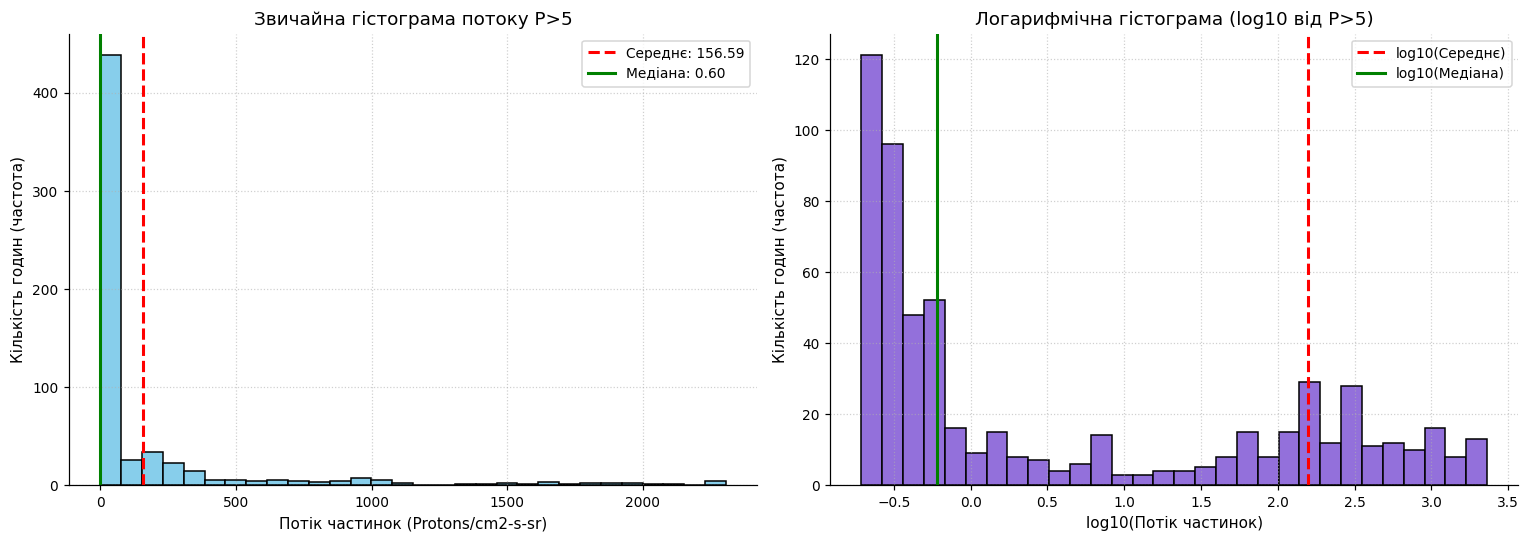

In [19]:
# ВАШ КОД
import matplotlib.pyplot as plt
import numpy as np

mean_val = M['P>5_mean'].mean()
median_val = M['P>5_mean'].median()

print(f"Середнє значення P>5: {mean_val:.4f}")
print(f"Медіана P>5:          {median_val:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(M['P>5_mean'], bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Середнє: {mean_val:.2f}')
axes[0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Медіана: {median_val:.2f}')
axes[0].set_title("Звичайна гістограма потоку P>5", fontsize=12)
axes[0].set_xlabel("Потік частинок (Protons/cm2-s-sr)", fontsize=10)
axes[0].set_ylabel("Кількість годин (частота)", fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

log_data = np.log10(M['P>5_mean'])

axes[1].hist(log_data, bins=30, color='mediumpurple', edgecolor='black')
axes[1].axvline(np.log10(mean_val), color='red', linestyle='--', linewidth=2, label=f'log10(Середнє)')
axes[1].axvline(np.log10(median_val), color='green', linestyle='-', linewidth=2, label=f'log10(Медіана)')
axes[1].set_title("Логарифмічна гістограма (log10 від P>5)", fontsize=12)
axes[1].set_xlabel("log10(Потік частинок)", fontsize=10)
axes[1].set_ylabel("Кількість годин (частота)", fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()


**Висновок:**

На графіку бачимо, що більшість годин потік протонів не перевищує 1 частинки, проте під час поодиноких сонячних спалахів він зростає у тисячі разів (понад 2000)
Середнє значення (156.69) і медіана (0.60) сильно відрізняються через асиметрію розподілу та наявність аномальних викидів. Медіана є числом посередині впорядкованого набору даних, тому вона показує типовий рівень потоку, на який припадає більшість годин. А середнє арифметичне збільшується через наявність поодиноких великих спалахів (як от 2000)


### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

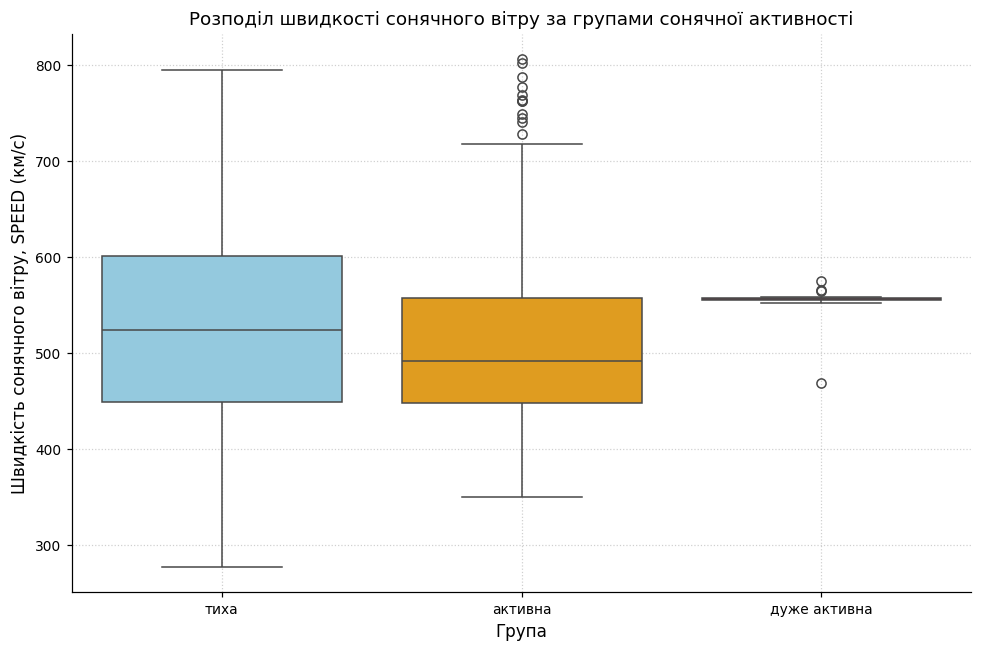

In [20]:
# ВАШ КОД
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

group_order = ['тиха', 'активна', 'дуже активна']

sns.boxplot(
    data=M,
    x='група',
    y='SPEED',
    order=group_order,
    hue='група',
    legend=False,
    palette=['skyblue', 'orange', 'crimson']
)

plt.title("Розподіл швидкості сонячного вітру за групами сонячної активності", fontsize=12)
plt.xlabel("Група", fontsize=11)
plt.ylabel("Швидкість сонячного вітру, SPEED (км/с)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Висновок:**

Чіткої прямої залежності між зростанням сонячної активності та швидкістю вітру немає - медіанна швидкість вітру в усіх трьох групах залишається приблизно однаковою (близько 480–580 км/с).
Проте групи сильно відрізняються за розподілом - в «тихій» та «активній» групах спостерігається значно більший розкид значень, ніж у групі «дуже активна», бо вона охоплює лише 18 годин. Також можемо бачити що саме група "активна" має найбільше аномальних сплесків швидкостів (до 800 км/с)

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції Пірсона між F10.7 та SPEED: 0.0593


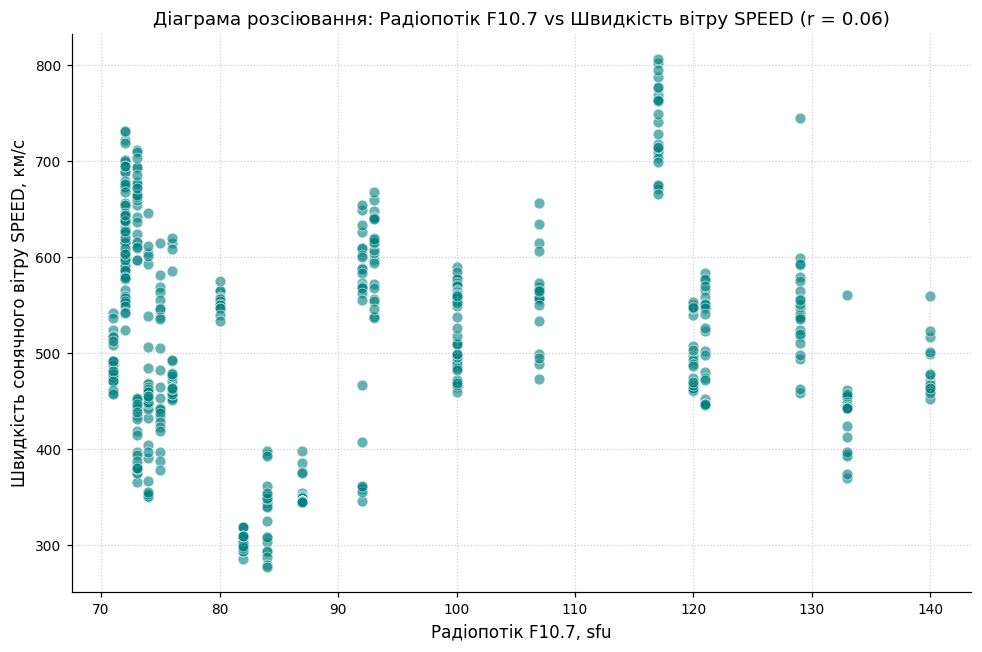

In [21]:
# ВАШ КОД
import matplotlib.pyplot as plt
import seaborn as sns

clean_data = M[['F10.7', 'SPEED']].dropna()
corr_val = clean_data['F10.7'].corr(clean_data['SPEED'])

print(f"Коефіцієнт кореляції Пірсона між F10.7 та SPEED: {corr_val:.4f}")

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=clean_data,
    x='F10.7',
    y='SPEED',
    alpha=0.6,
    color='teal',
    edgecolor='w',
    s=50
)

plt.title(f"Діаграма розсіювання: Радіопотік F10.7 vs Швидкість вітру SPEED (r = {corr_val:.2f})", fontsize=12)
plt.xlabel("Радіопотік F10.7, sfu", fontsize=11)
plt.ylabel("Швидкість сонячного вітру SPEED, км/с", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Висновок:**

Точки на діаграмі розсіювання розміщені хаотично без вираженого тренду, а значення коефіцієнта кореляції Пірсона (0.0593) свідчить про повну відсутність лінійного зв'язку між радіопотоком F10.7 та швидкістю сонячного вітру. Тобто, збільшення радіопотоку ніяк не впливає на швидкість сонячного вітру

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

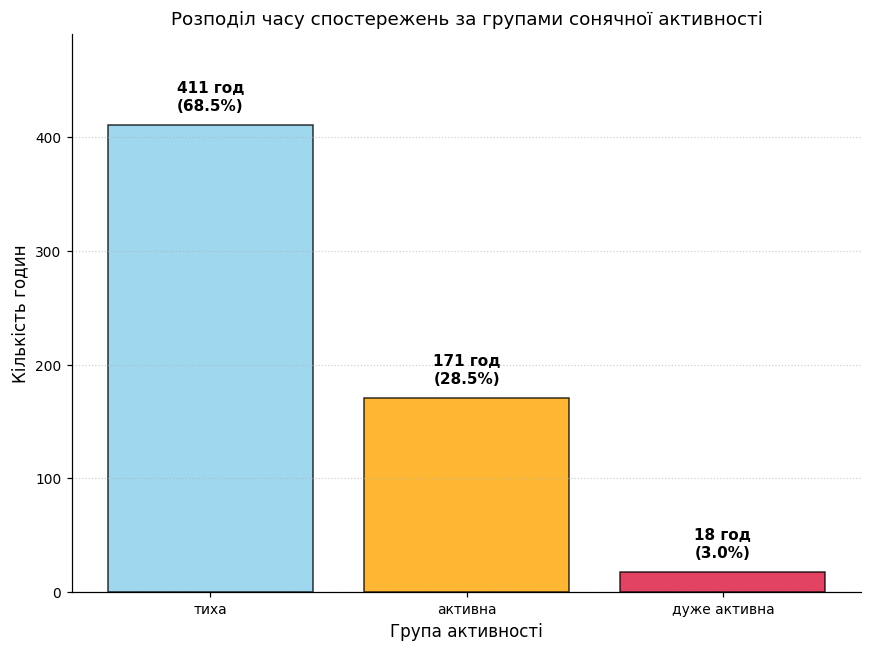

In [22]:
# ВАШ КОД
import matplotlib.pyplot as plt
import seaborn as sns

group_counts = M['група'].value_counts().reindex(['тиха', 'активна', 'дуже активна'])
total_hours = len(M)

plt.figure(figsize=(8, 6))
colors = ['skyblue', 'orange', 'crimson']

bars = plt.bar(group_counts.index, group_counts.values, color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total_hours) * 100
    label_text = f"{int(height)} год\n({percentage:.1f}%)"

    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 10,
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Розподіл часу спостережень за групами сонячної активності", fontsize=12)
plt.xlabel("Група активності", fontsize=11)
plt.ylabel("Кількість годин", fontsize=11)
plt.ylim(0, max(group_counts.values) + 80)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Висновок:**

Переважну більшість часу спостережень (68.5%, 411 годин) Сонце перебувало у «тихому» стані, на «активну» фазу припало 28.5% часу (171 година), а стан «дуже активна» спостерігався лише протягом 3.0% часу (18 годин).

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

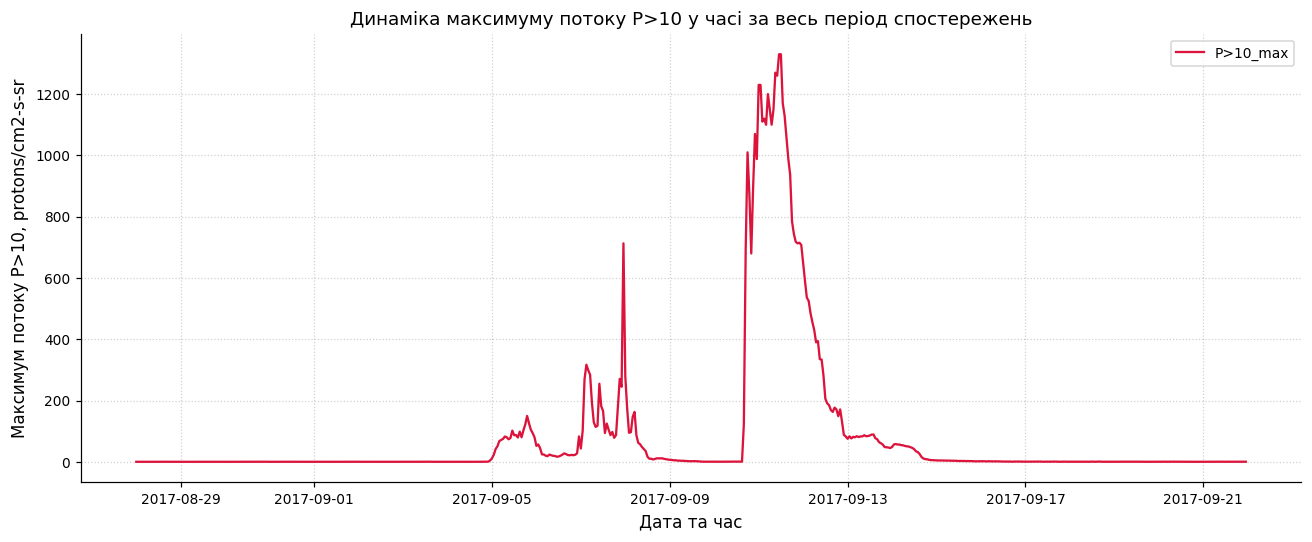

In [23]:
# ВАШ КОД
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(M['ts'], M['P>10_max'], color='crimson', linewidth=1.5, label='P>10_max')

plt.title("Динаміка максимуму потоку P>10 у часі за весь період спостережень", fontsize=12)
plt.xlabel("Дата та час", fontsize=11)
plt.ylabel("Максимум потоку P>10, protons/cm2-s-sr", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

**Висновок:**
У часовому розподілі максимального потоку P>10 можемо побачити тривалий період спокою до 5 вересня, після чого починається серія сплесків та найсильніший пік у період приблизно з 10 по 12 вересня, після чого потік поступово згасає

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

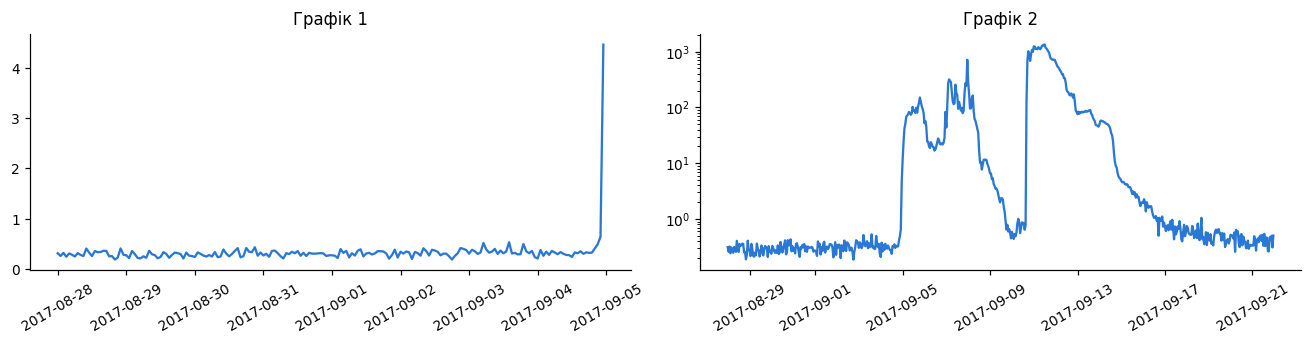

In [24]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Космічна погода було спокійною протягом вересня, і лише 5 вересня стався один невеликий сплеск (потік зріс близько до 4)
2. Висновок з другого графіка: У вересні відбулося два сильні сонячні спалахи: перший 5-8 вересня, другий 10-13 вересня, де потік перевищив 1000
3. Дві відмінності між ними: Перша відмінність полягає у тому, що в першому графіку обрано обмежене вікно часу з 28 серпня по 5 вересня, в той час як у другому графіку показується весь період спостережень. Друга відмінність - на першому графіку звичайна лінійна шкала, а на другому - логарифмічна


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

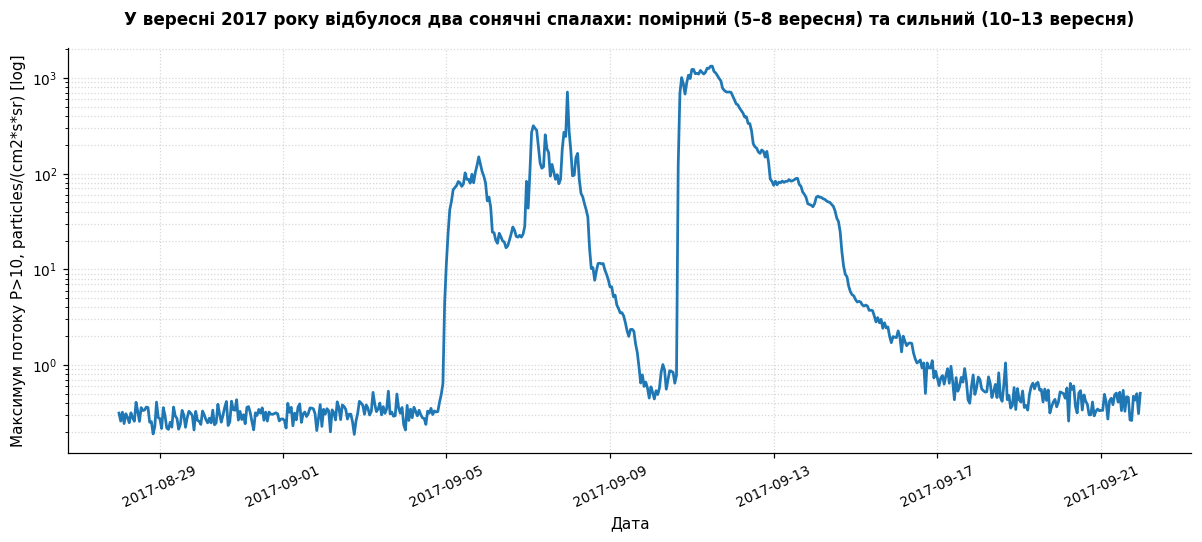

In [25]:
# ВАШ КОД
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))

plt.plot(M['ts'], M['P>10_max'], color='#1f77b4', linewidth=1.8, label='P>10_max')
plt.yscale('log')

plt.title("У вересні 2017 року відбулося два сонячні спалахи: помірний (5–8 вересня) та сильний (10–13 вересня)",
          fontsize=11, fontweight='bold', pad=15)

plt.xlabel("Дата", fontsize=10)
plt.ylabel("Максимум потоку P>10, particles/(cm2*s*sr) [log]", fontsize=10)
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

По-перше, було обрано весь проміжок спостереження, щоб не втрачалась жодна важлива подія (як спалахи)

По-друге, потік частинок має великий розмах значень (від менше ніж 1 до 1000), тому була обрана логарифмічна шкала, оскільки вона дозволяє чіткіше показати як дрібні коливання, так і спалахи

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Рівень потоку P>10 у спокійні дні становить менше 1, але під час найсильнішого спалаху протягом 10-13 вересня він зростав у понад 1300 разів (графік 5, графік 6.2)

**Спостереження 2:** Стан «тихої» сонячної погоди спостерігається майже у 23 рази частіше (411 годин, або 68.5%), ніж стан «дуже активна» (18 годин, 3.0%), що підтверджує рідкісний характер екстремальних спалахів (графік 4)

**Спостереження 3:** Через рідкісні, але сильні спалахи розподіл потоку P>5 є  асиметричним: його середнє значення (156.69) перевищує медіану (0.60) у понад 260 разів (графік 1)


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
# ВАШ КОД
daily_mean = M.groupby(M['ts'].dt.date)['P>5_mean'].mean()

max_date = daily_mean.idxmax()
max_value = daily_mean.max()

min_date = daily_mean.idxmin()
min_value = daily_mean.min()

print(f"Максимальне середньодобове значення: {max_value:.3f} (дата: {max_date})")
print(f"Мінімальне середньодобове значення: {min_value:.3f} (дата: {min_date})")

Максимальне середньодобове значення: 1693.983 (дата: 2017-09-11)
Мінімальне середньодобове значення: 0.241 (дата: 2017-08-29)


**Відповідь 7.2:**
Індивідуальне питання: У яку добу середнє значення вашого потоку було найбільшим? А найменшим? (потік P>5)

За результатами обчислень, найбільше середньодобове значення потоку P>5 становило 1693.983 та було 11.09.2017 (що відповідає піковій фазі сонячного спалаху), а мінімальне значення значення 0.241 було 29.08.2017, що відповідає фазі спокою

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'ШІ допомагав з синтаксисом та використанням деяких окремих функцій(1-3 етапи), та з написанням повного коду для усіх графіків та побудови таблиці M; деякі висновки частково допомагав правильно сформулювати ШІ, але всі числа, результати обчислень тощо були проаналізовані самостійно'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Потапова Світлана
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
ШІ допомагав з синтаксисом та використанням деяких окремих функцій(1-3 етапи), та з написанням повного коду для усіх графіків та побудови таблиці M; деякі висновки частково допомагав правильно сформулювати ШІ, але всі числа, результати обчислень тощо були проаналізовані самостійно
Автор підтверджує, щ

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
